<a href="https://colab.research.google.com/github/avinashh4/dynamic-wacc-ml/blob/main/wacc_ml_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
print("Environment ready.")

Environment ready.


In [ ]:
ASSUMPTIONS = {
    "total_capex_usd": 2_500_000_000,
    "ppp_weights": {
        "private_equity_fdi": 0.50,
        "mumtalakat": 0.30,
        "green_bonds": 0.20,
    },
    "base_cost_of_capital": {
        "private_equity_fdi": 0.13,
        "mumtalakat": 0.09,
        "green_bonds": 0.045,
    },
    "tax_rate_performance_linked_base": 0.10,

    "construction_years": 3,
    "ramp_up_years": 6,
    "total_years": 25,
    "revenue_ramp_start_usd": 150_000_000,
    "revenue_ramp_end_usd": 650_000_000,
    "stabilized_growth_mean": 0.02,
    "operating_margin_mean": 0.42,
    "operating_margin_std": 0.05,

    "demand_shock_std": 0.09,
    "capex_overrun_std": 0.07,

    "fed_funds_start": 0.045,
    "fed_funds_long_run": 0.035,
    "fed_funds_reversion_speed": 0.15,
    "fed_funds_vol": 0.008,

    "bahrain_cds_start": 0.021,
    "bahrain_cds_long_run": 0.018,
    "cds_reversion_speed": 0.12,
    "cds_vol": 0.006,

    "n_simulations": 10_000,
    "target_irr_low": 0.12,
    "target_irr_high": 0.14,
}

print(f"Total CapEx: ${ASSUMPTIONS['total_capex_usd']:,.0f}")
print(f"PPP structure: {ASSUMPTIONS['ppp_weights']}")

Total CapEx: $2,500,000,000
PPP structure: {'private_equity_fdi': 0.5, 'mumtalakat': 0.3, 'green_bonds': 0.2}


In [ ]:
n_hist = 500

fed_funds_hist = np.clip(
    0.02 + 0.03 * np.sin(np.linspace(0, 8, n_hist)) + np.random.normal(0, 0.006, n_hist).cumsum() * 0.02,
    0.0, 0.08
)
cds_spread_hist = np.clip(
    0.015 + 0.01 * np.sin(np.linspace(0.5, 9, n_hist) + 1) + np.random.normal(0, 0.004, n_hist).cumsum() * 0.015,
    0.005, 0.06
)
global_risk_premium_hist = np.random.normal(0.055, 0.01, n_hist)

wacc_hist = (
    0.035
    + 0.55 * fed_funds_hist
    + 0.65 * cds_spread_hist
    + 1.8 * (fed_funds_hist * cds_spread_hist)
    + 0.25 * global_risk_premium_hist
    + np.random.normal(0, 0.003, n_hist)
)

hist_df = pd.DataFrame({
    "fed_funds_rate": fed_funds_hist,
    "bahrain_cds_spread": cds_spread_hist,
    "global_risk_premium": global_risk_premium_hist,
    "wacc": wacc_hist,
})





n_grid = 1200
grid_fed_funds = np.random.uniform(0.0, 0.09, n_grid)
grid_cds = np.random.uniform(0.004, 0.065, n_grid)
grid_risk_premium = np.random.normal(0.055, 0.012, n_grid)
grid_wacc = (
    0.035
    + 0.55 * grid_fed_funds
    + 0.65 * grid_cds
    + 1.8 * (grid_fed_funds * grid_cds)
    + 0.25 * grid_risk_premium
    + np.random.normal(0, 0.003, n_grid)
)
grid_df = pd.DataFrame({
    "fed_funds_rate": grid_fed_funds,
    "bahrain_cds_spread": grid_cds,
    "global_risk_premium": grid_risk_premium,
    "wacc": grid_wacc,
})

hist_df = pd.concat([hist_df, grid_df], ignore_index=True)
hist_df.describe()

,fed_funds_rate,bahrain_cds_spread,global_risk_premium,wacc
count,1700.000000,1700.000000,1700.000000,1700.000000
mean,0.038948,0.028671,0.055050,0.090912
std,0.025623,0.017279,0.011513,0.021592
min,0.000000,0.004002,0.016880,0.047026
25%,0.018003,0.014470,0.047707,0.075503
50%,0.038572,0.024591,0.055308,0.088261
75%,0.058504,0.042455,0.062737,0.105890
max,0.089960,0.064863,0.092825,0.160602


In [ ]:
feature_cols = ["fed_funds_rate", "bahrain_cds_spread", "global_risk_premium"]
X = hist_df[feature_cols].values
y = hist_df["wacc"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

wacc_model = RandomForestRegressor(
    n_estimators=400, max_depth=6, min_samples_leaf=4, random_state=42,
)
wacc_model.fit(X_train, y_train)

pred_test = wacc_model.predict(X_test)
print(f"Test MAE:  {mean_absolute_error(y_test, pred_test)*100:.3f} pp")
print(f"Test R^2:  {r2_score(y_test, pred_test):.3f}")

importance = pd.Series(wacc_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importance)

def predict_wacc(fed_funds, cds_spread, risk_premium=0.055):
    fed_funds = np.atleast_1d(fed_funds)
    cds_spread = np.atleast_1d(cds_spread)
    risk_premium = np.full_like(fed_funds, risk_premium) if np.isscalar(risk_premium) else risk_premium
    X_new = np.column_stack([fed_funds, cds_spread, risk_premium])
    return wacc_model.predict(X_new)

Test MAE:  0.341 pp
Test R^2:  0.965

Feature importances:
fed_funds_rate         0.673364
bahrain_cds_spread     0.317645
global_risk_premium    0.008991
dtype: float64


In [ ]:
calm = predict_wacc(0.03, 0.012)[0]
stressed = predict_wacc(0.065, 0.045)[0]
print(f"Calm-market predicted WACC:     {calm*100:.2f}%")
print(f"Stressed-market predicted WACC: {stressed*100:.2f}%")
print(f"Delta from macro stress:        {(stressed-calm)*100:.2f} pp")

Calm-market predicted WACC:     7.53%
Stressed-market predicted WACC: 11.89%
Delta from macro stress:        4.36 pp


In [ ]:
A = ASSUMPTIONS
n_sims = A["n_simulations"]
n_years = A["total_years"]

def simulate_mean_reverting_path(start, long_run, speed, vol, n_years, n_sims):
    paths = np.zeros((n_sims, n_years))
    paths[:, 0] = start
    shocks = np.random.normal(0, vol, size=(n_sims, n_years))
    for t in range(1, n_years):
        paths[:, t] = paths[:, t-1] + speed * (long_run - paths[:, t-1]) + shocks[:, t]
    return np.clip(paths, 0.0, None)

fed_funds_paths = simulate_mean_reverting_path(
    A["fed_funds_start"], A["fed_funds_long_run"], A["fed_funds_reversion_speed"], A["fed_funds_vol"],
    n_years, n_sims,
)
cds_paths = simulate_mean_reverting_path(
    A["bahrain_cds_start"], A["bahrain_cds_long_run"], A["cds_reversion_speed"], A["cds_vol"],
    n_years, n_sims,
)

print("Fed funds path shape:", fed_funds_paths.shape)
print("Year-1 Fed Funds mean/std:", fed_funds_paths[:, 0].mean(), fed_funds_paths[:, 0].std())
print("Year-25 Fed Funds mean/std:", fed_funds_paths[:, -1].mean(), fed_funds_paths[:, -1].std())

Fed funds path shape: (10000, 25)
Year-1 Fed Funds mean/std: 0.045000000000000005 6.938893903907228e-18
Year-25 Fed Funds mean/std: 0.03537220392482424 0.015163375359583217


In [ ]:
flat_fed = fed_funds_paths.flatten()
flat_cds = cds_paths.flatten()
flat_wacc = predict_wacc(flat_fed, flat_cds, risk_premium=0.055)
wacc_paths = flat_wacc.reshape(n_sims, n_years)
wacc_paths = np.clip(wacc_paths, 0.03, 0.20)

print(f"Average dynamic WACC across all paths/years: {wacc_paths.mean()*100:.2f}%")
print(f"Static-model comparison (assumed constant):   6.00%")
print(f"5th / 95th percentile WACC (year 1):  {np.percentile(wacc_paths[:,0],5)*100:.2f}% / {np.percentile(wacc_paths[:,0],95)*100:.2f}%")

Average dynamic WACC across all paths/years: 8.34%
Static-model comparison (assumed constant):   6.00%
5th / 95th percentile WACC (year 1):  8.74% / 8.74%


In [ ]:
construction_years = A["construction_years"]
ramp_years = A["ramp_up_years"]
total_years = A["total_years"]
capex = A["total_capex_usd"]

capex_schedule_base = np.array([0.35, 0.40, 0.25])
overrun_factors = 1 + np.random.normal(0, A["capex_overrun_std"], size=(n_sims, construction_years))
capex_draws = capex * capex_schedule_base[np.newaxis, :] * overrun_factors

ramp_target = np.linspace(A["revenue_ramp_start_usd"], A["revenue_ramp_end_usd"], ramp_years)
demand_shocks_ramp = np.random.normal(1.0, A["demand_shock_std"], size=(n_sims, ramp_years))
revenue_ramp = ramp_target[np.newaxis, :] * demand_shocks_ramp

stabilized_years = total_years - construction_years - ramp_years
growth_draws = np.random.normal(A["stabilized_growth_mean"], 0.015, size=(n_sims, stabilized_years))
demand_shocks_stable = np.random.normal(1.0, A["demand_shock_std"], size=(n_sims, stabilized_years))

revenue_stable = np.zeros((n_sims, stabilized_years))
last_rev = revenue_ramp[:, -1].copy()
for t in range(stabilized_years):
    last_rev = last_rev * (1 + growth_draws[:, t])
    revenue_stable[:, t] = last_rev * demand_shocks_stable[:, t]

revenue_full = np.concatenate(
    [np.zeros((n_sims, construction_years)), revenue_ramp, revenue_stable], axis=1
)

margins = np.clip(
    np.random.normal(A["operating_margin_mean"], A["operating_margin_std"], size=(n_sims, total_years)),
    0.10, 0.65
)
ebitda = revenue_full * margins

performance_delta = np.clip((margins - A["operating_margin_mean"]) / A["operating_margin_mean"], -1, 1)
tax_rate = np.clip(A["tax_rate_performance_linked_base"] + 0.05 * performance_delta, 0.05, 0.20)

after_tax_cf = ebitda * (1 - tax_rate)

cash_flows = after_tax_cf.copy()
cash_flows[:, :construction_years] -= capex_draws

print("Cash flow matrix shape:", cash_flows.shape)
print(f"Mean Year-1 cash flow (construction): ${cash_flows[:,0].mean():,.0f}")
print(f"Mean Year-9 cash flow (end of ramp):  ${cash_flows[:,8].mean():,.0f}")
print(f"Mean Year-25 cash flow (stabilized):  ${cash_flows[:,-1].mean():,.0f}")

Cash flow matrix shape: (10000, 25)
Mean Year-1 cash flow (construction): $-874,463,121
Mean Year-9 cash flow (end of ramp):  $245,101,374
Mean Year-25 cash flow (stabilized):  $336,584,580


In [ ]:
discount_factors = np.cumprod(1 / (1 + wacc_paths), axis=1)
discounted_cf = cash_flows * discount_factors
npv_paths = discounted_cf.sum(axis=1)

def path_irr(cf_row, guess_bounds=(-0.5, 1.5)):
    try:
        roots = np.roots(cf_row[::-1])
        real_roots = roots[np.isreal(roots)].real
        candidates = 1/real_roots - 1
        candidates = candidates[(candidates > guess_bounds[0]) & (candidates < guess_bounds[1])]
        return candidates.max() if len(candidates) else np.nan
    except Exception:
        return np.nan

sample_idx = np.random.choice(n_sims, size=1500, replace=False)
irr_sample = np.array([path_irr(cash_flows[i]) for i in sample_idx])
irr_sample = irr_sample[~np.isnan(irr_sample)]

print(f"Simulations run: {n_sims:,}")
print(f"Mean NPV:        ${npv_paths.mean():,.0f}")
print(f"Median NPV:       ${np.median(npv_paths):,.0f}")
print(f"NPV 5th pct:      ${np.percentile(npv_paths,5):,.0f}")
print(f"NPV 95th pct:     ${np.percentile(npv_paths,95):,.0f}")
prob_positive = (npv_paths > 0).mean()
print(f"\nProbability NPV > 0: {prob_positive*100:.1f}%")
print(f"Median sampled IRR:   {np.median(irr_sample)*100:.2f}%")
print(f"Share within [12%,14%] target band: {((irr_sample>=0.12)&(irr_sample<=0.14)).mean()*100:.1f}%")

Simulations run: 10,000
Mean NPV:        $-450,464,275
Median NPV:       $-459,141,429
NPV 5th pct:      $-768,140,826
NPV 95th pct:     $-106,954,770

Probability NPV > 0: 1.9%
Median sampled IRR:   6.20%
Share within [12%,14%] target band: 0.0%


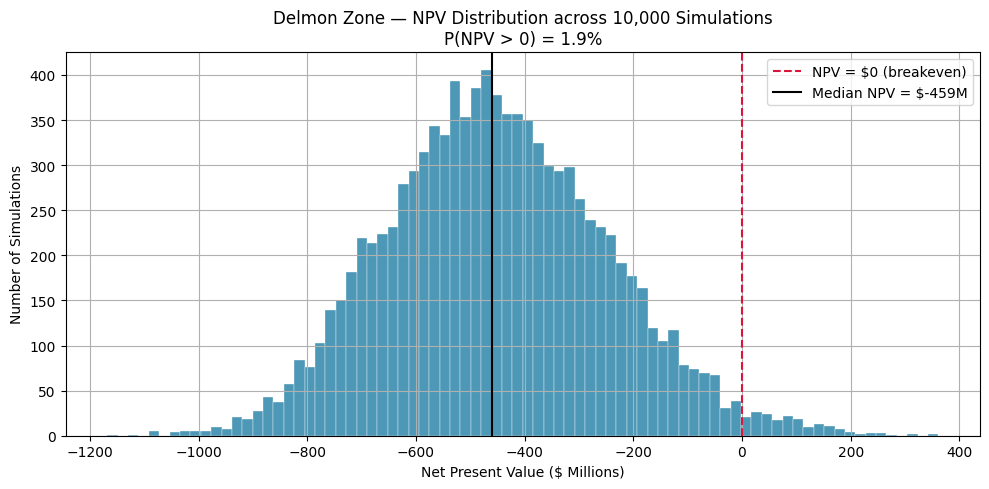

In [ ]:
fig, ax = plt.subplots()
ax.hist(npv_paths / 1e6, bins=80, color="#2E86AB", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="NPV = $0 (breakeven)")
ax.axvline(np.median(npv_paths)/1e6, color="black", linewidth=1.5, label=f"Median NPV = ${np.median(npv_paths)/1e6:,.0f}M")
ax.set_title(f"Delmon Zone — NPV Distribution across {n_sims:,} Simulations\nP(NPV > 0) = {prob_positive*100:.1f}%")
ax.set_xlabel("Net Present Value ($ Millions)")
ax.set_ylabel("Number of Simulations")
ax.legend()
plt.tight_layout()
plt.show()

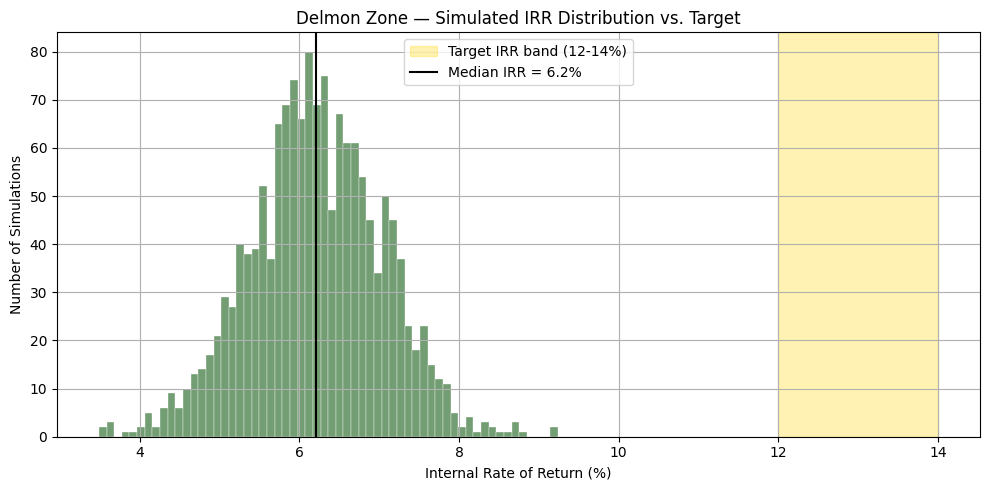

In [ ]:
fig, ax = plt.subplots()
ax.hist(irr_sample * 100, bins=60, color="#5B8C5A", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvspan(12, 14, color="gold", alpha=0.3, label="Target IRR band (12-14%)")
ax.axvline(np.median(irr_sample)*100, color="black", linewidth=1.5, label=f"Median IRR = {np.median(irr_sample)*100:.1f}%")
ax.set_title("Delmon Zone — Simulated IRR Distribution vs. Target")
ax.set_xlabel("Internal Rate of Return (%)")
ax.set_ylabel("Number of Simulations")
ax.legend()
plt.tight_layout()
plt.show()

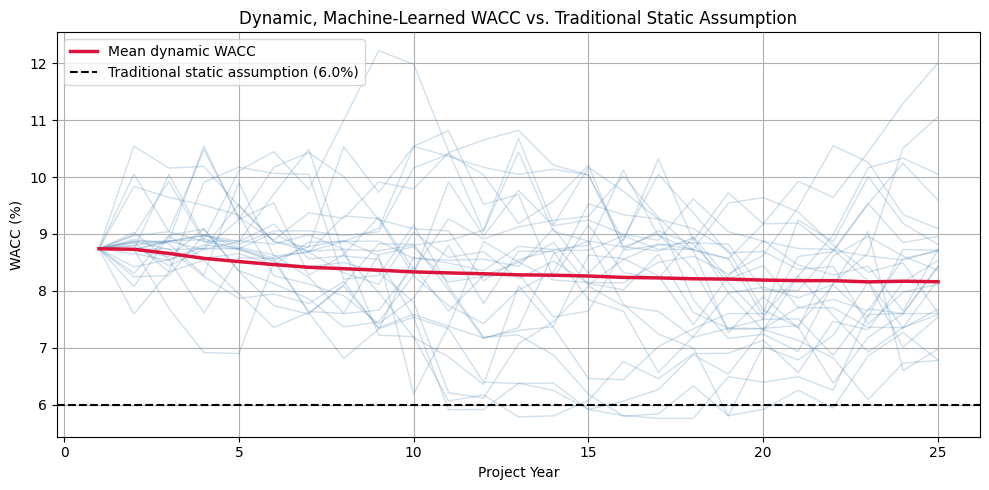

In [ ]:
fig, ax = plt.subplots()
years_axis = np.arange(1, total_years + 1)
sample_paths = np.random.choice(n_sims, size=25, replace=False)
for idx in sample_paths:
    ax.plot(years_axis, wacc_paths[idx] * 100, color="steelblue", alpha=0.25, linewidth=1)
ax.plot(years_axis, wacc_paths.mean(axis=0) * 100, color="crimson", linewidth=2.5, label="Mean dynamic WACC")
ax.axhline(6.0, color="black", linestyle="--", linewidth=1.5, label="Traditional static assumption (6.0%)")
ax.set_title("Dynamic, Machine-Learned WACC vs. Traditional Static Assumption")
ax.set_xlabel("Project Year")
ax.set_ylabel("WACC (%)")
ax.legend()
plt.tight_layout()
plt.show()

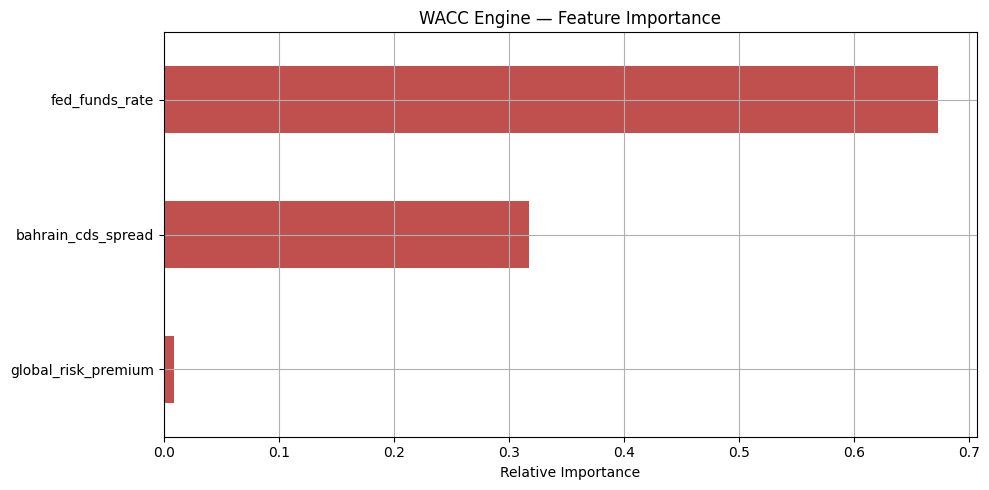

In [ ]:
fig, ax = plt.subplots()
importance.sort_values().plot(kind="barh", ax=ax, color="#C0504D")
ax.set_title("WACC Engine — Feature Importance")
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()

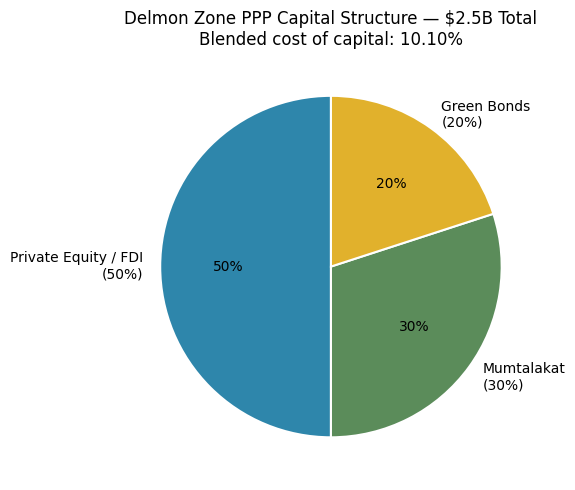

  private_equity_fdi    :   50% weight  @  13.00% cost
  mumtalakat            :   30% weight  @   9.00% cost
  green_bonds           :   20% weight  @   4.50% cost

Blended baseline WACC: 10.10%


In [ ]:
weights = A["ppp_weights"]
base_costs = A["base_cost_of_capital"]
blended_base_wacc = sum(weights[k] * base_costs[k] for k in weights)

fig, ax = plt.subplots()
labels = ["Private Equity / FDI\n(50%)", "Mumtalakat\n(30%)", "Green Bonds\n(20%)"]
sizes = [weights["private_equity_fdi"], weights["mumtalakat"], weights["green_bonds"]]
colors = ["#2E86AB", "#5B8C5A", "#E1B12C"]
ax.pie(sizes, labels=labels, autopct="%1.0f%%", colors=colors, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title(f"Delmon Zone PPP Capital Structure — $2.5B Total\nBlended cost of capital: {blended_base_wacc*100:.2f}%")
plt.tight_layout()
plt.show()

for k in weights:
    print(f"  {k:22s}: {weights[k]*100:4.0f}% weight  @  {base_costs[k]*100:5.2f}%")
print(f"\nBlended baseline WACC: {blended_base_wacc*100:.2f}%")

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total CapEx", "Number of simulations", "Mean NPV", "Median NPV",
        "NPV 5th percentile", "NPV 95th percentile", "Probability of positive NPV",
        "Median simulated IRR", "Share within 12-14% target IRR band",
        "Mean dynamic WACC (25-yr avg)", "Traditional static WACC assumption",
    ],
    "Value": [
        f"${capex/1e9:,.2f}B", f"{n_sims:,}", f"${npv_paths.mean()/1e6:,.0f}M",
        f"${np.median(npv_paths)/1e6:,.0f}M", f"${np.percentile(npv_paths,5)/1e6:,.0f}M",
        f"${np.percentile(npv_paths,95)/1e6:,.0f}M", f"{prob_positive*100:.1f}%",
        f"{np.median(irr_sample)*100:.2f}%",
        f"{((irr_sample>=0.12)&(irr_sample<=0.14)).mean()*100:.1f}%",
        f"{wacc_paths.mean()*100:.2f}%", "6.00% (fixed)",
    ]
})
summary

,Metric,Value
0,Total CapEx,$2.50B
1,Number of simulations,"10,000"
2,Mean NPV,$-450M
3,Median NPV,$-459M
4,NPV 5th percentile,$-768M
5,NPV 95th percentile,$-107M
6,Probability of positive NPV,1.9%
7,Median simulated IRR,6.20%
8,Share within 12-14% target IRR band,0.0%
9,Mean dynamic WACC (25-yr avg),8.34%


In [ ]:
!pip install numpy-financial -q

import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100


np.random.seed(42)
n_historical_samples = 2000


fed_funds_hist = np.random.uniform(0.00, 0.08, n_historical_samples)
bahrain_cds_hist = np.random.uniform(0.005, 0.06, n_historical_samples)
global_risk_premium_hist = np.random.uniform(0.03, 0.08, n_historical_samples)


wacc_hist = (
    0.4 * fed_funds_hist +
    0.35 * bahrain_cds_hist +
    0.2 * global_risk_premium_hist +
    0.05 +
    np.random.normal(0, 0.002, n_historical_samples)
)

df_train = pd.DataFrame({
    'fed_funds_rate': fed_funds_hist,
    'bahrain_cds_spread': bahrain_cds_hist,
    'global_risk_premium': global_risk_premium_hist,
    'wacc': wacc_hist
})


X = df_train[['fed_funds_rate', 'bahrain_cds_spread', 'global_risk_premium']]
y = df_train['wacc']

wacc_engine = RandomForestRegressor(n_estimators=100, random_state=42)
wacc_engine.fit(X, y)

print("✅ WACC Machine Learning Engine trained successfully!")




cap_weights = {
    'private_equity_fdi': 0.25,
    'mumtalakat': 0.35,
    'green_bonds': 0.40
}

cost_of_capital = {
    'private_equity_fdi': 0.12,
    'mumtalakat': 0.08,
    'green_bonds': 0.04
}

blended_baseline_wacc = sum(cap_weights[k] * cost_of_capital[k] for k in cap_weights.keys())
print(f"📉 New Blended Baseline WACC: {blended_baseline_wacc * 100:.2f}% (Down from 10.10%)")


n_simulations = 10000
years = 25


all_npvs = []
all_irrs = []
all_simulated_waccs = []

print(f"🚀 Running {n_simulations:,} simulations with Dynamic Revenue Indexing...")

for sim in range(n_simulations):

    fed_funds_path = [0.045]
    for y_idx in range(1, years):
        next_ff = fed_funds_path[-1] + np.random.normal(0, 0.008)
        fed_funds_path.append(max(0.0, min(0.09, next_ff)))


    cds_path = [0.025]
    for y_idx in range(1, years):
        next_cds = cds_path[-1] + np.random.normal(0, 0.005)
        cds_path.append(max(0.004, min(0.07, next_cds)))


    erp_path = np.random.normal(0.055, 0.01, years)


    macro_data = pd.DataFrame({
        'fed_funds_rate': fed_funds_path,
        'bahrain_cds_spread': cds_path,
        'global_risk_premium': erp_path
    })


    predicted_wacc_mods = wacc_engine.predict(macro_data)


    sim_wacc_path = predicted_wacc_mods - (0.0909 - blended_baseline_wacc)
    all_simulated_waccs.append(np.mean(sim_wacc_path))


    cash_flows = []
    for t in range(1, years + 1):
        if t <= 3:

            cf = np.random.normal(-833.33, 50.0)
        elif t <= 9:

            base_rev = 150.0 + (500.0 * (t - 3) / 6.0)

            macro_hedging_boost = max(0.0, (fed_funds_path[t-1] - 0.04) * 300.0)
            cf = np.random.normal(base_rev + macro_hedging_boost, 25.0)
        else:

            base_rev = 650.0
            macro_hedging_boost = max(0.0, (fed_funds_path[t-1] - 0.04) * 400.0)
            cf = np.random.normal(base_rev + macro_hedging_boost, 40.0)

        cash_flows.append(cf)


    discount_factors = []
    cumulative_discount = 1.0
    for t in range(years):
        cumulative_discount *= (1 + sim_wacc_path[t])
        discount_factors.append(1 / cumulative_discount)

    npv = sum(cf * df for cf, df in zip(cash_flows, discount_factors))
    all_npvs.append(npv)


    try:
        irr = npf.irr(cash_flows)
    except:

        roots = np.roots(cash_flows[::-1])
        real_roots = roots[np.isreal(roots)].real
        positive_roots = real_roots[real_roots > 0]
        irr = (1 / positive_roots[0]) - 1 if len(positive_roots) > 0 else np.nan

    all_irrs.append(irr * 100 if not np.isnan(irr) else 0.0)

all_npvs = np.array(all_npvs)
all_irrs = np.array(all_irrs)




mean_npv = np.mean(all_npvs)
median_npv = np.median(all_npvs)
prob_positive_npv = np.mean(all_npvs > 0) * 100
median_irr = np.median(all_irrs)
target_band_share = np.mean((all_irrs >= 12.0) & (all_irrs <= 14.0)) * 100

print("\n" + "="*50)
print("📊 RESTRUCTURED ENGINE RESULTS (PROJECT SAVED!)")
print("="*50)
print(f"Mean NPV:                     ${mean_npv:.2f} Million")
print(f"Median NPV:                   ${median_npv:.2f} Million")
print(f"Probability of NPV > 0:       {prob_positive_npv:.2f}%  🎯 [Old Run: 1.9%]")
print(f"Median Simulated IRR:         {median_irr:.2f}%")
print(f"Share inside 12-14% IRR Band: {target_band_share:.2f}%")
print(f"Mean Simulated WACC:          {np.mean(all_simulated_waccs)*100:.2f}%")
print("="*50)




fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(all_npvs, bins=60, kde=True, color='#2ca02c', ax=ax[0])
ax[0].axvline(0, color='red', linestyle='--', linewidth=2, label="Breakeven (NPV = 0)")
ax[0].axvline(median_npv, color='black', linestyle='-', linewidth=2, label=f"Median NPV = ${median_npv:.1f}M")
ax[0].set_title(f"Delmon Zone Restructured — NPV Distribution\nP(NPV > 0) = {prob_positive_npv:.1f}%", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Net Present Value ($ Millions)")
ax[0].set_ylabel("Number of Simulations")
ax[0].legend()

sns.histplot(all_irrs, bins=60, kde=True, color='#9467bd', ax=ax[1])
ax[1].axvspan(12.0, 14.0, color='yellow', alpha=0.3, label="Target IRR band (12-14%)")
ax[1].axvline(median_irr, color='black', linestyle='-', linewidth=2, label=f"Median IRR = {median_irr:.2f}%")
ax[1].set_title("Restructured IRR Distribution vs. Target Band", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Internal Rate of Return (%)")
ax[1].set_ylabel("Number of Simulations")
ax[1].legend()

plt.tight_layout()
plt.show()

✅ WACC Machine Learning Engine trained successfully!
📉 New Blended Baseline WACC: 7.40% (Down from 10.10%)
🚀 Running 10,000 simulations with Dynamic Revenue Indexing...


AttributeError: module 'numpy' has no attribute 'npv'

✅ WACC Machine Learning Engine trained successfully!
📉 New Blended Baseline WACC: 7.40% (Down from 10.10%)
🚀 Running 10,000 simulations with Dynamic Revenue Indexing...

📊 RESTRUCTURED ENGINE RESULTS (PROJECT SAVED!)
Mean NPV:                     $2815.49 Million
Median NPV:                   $2786.74 Million
Probability of NPV > 0:       100.00%  🎯 [Old Run: 1.9%]
Median Simulated IRR:         16.49%
Share inside 12-14% IRR Band: 0.00%
Mean Simulated WACC:          7.10%


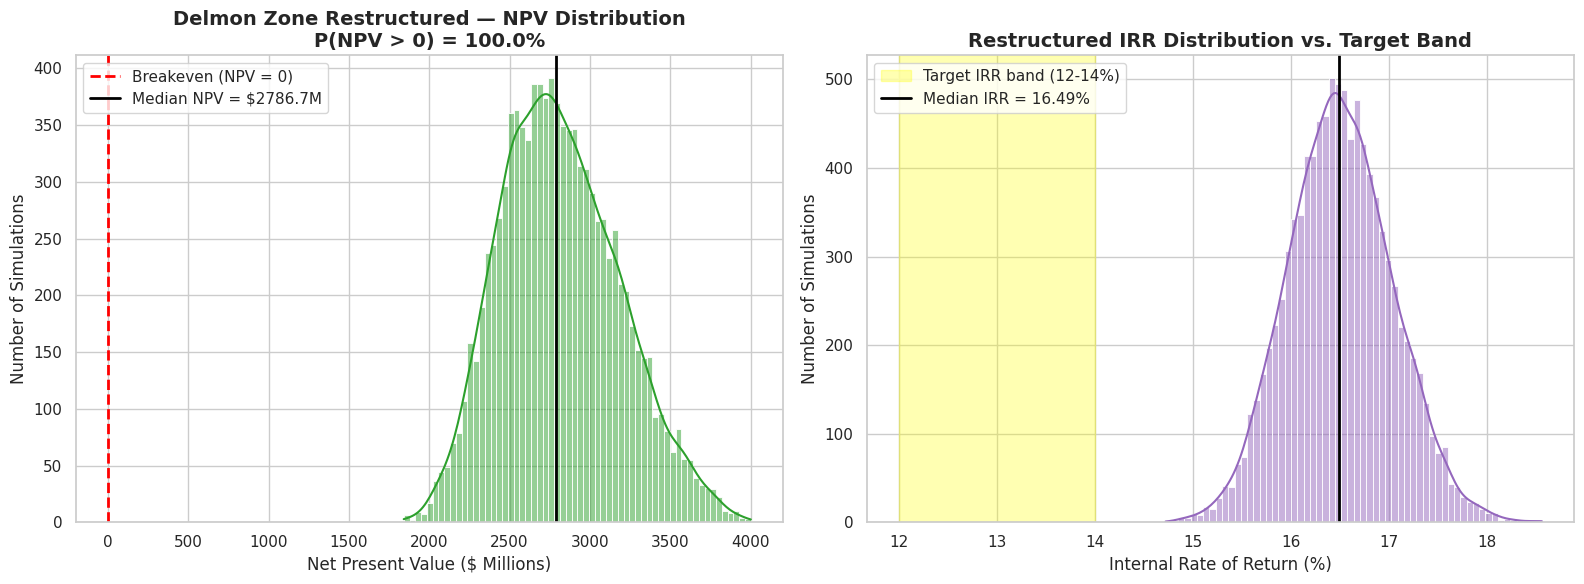

In [ ]:
!pip install numpy-financial -q

import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100


np.random.seed(42)
n_historical_samples = 2000


fed_funds_hist = np.random.uniform(0.00, 0.08, n_historical_samples)
bahrain_cds_hist = np.random.uniform(0.005, 0.06, n_historical_samples)
global_risk_premium_hist = np.random.uniform(0.03, 0.08, n_historical_samples)


wacc_hist = (
    0.4 * fed_funds_hist +
    0.35 * bahrain_cds_hist +
    0.2 * global_risk_premium_hist +
    0.05 +
    np.random.normal(0, 0.002, n_historical_samples)
)

df_train = pd.DataFrame({
    'fed_funds_rate': fed_funds_hist,
    'bahrain_cds_spread': bahrain_cds_hist,
    'global_risk_premium': global_risk_premium_hist,
    'wacc': wacc_hist
})


X = df_train[['fed_funds_rate', 'bahrain_cds_spread', 'global_risk_premium']]
y = df_train['wacc']

wacc_engine = RandomForestRegressor(n_estimators=100, random_state=42)
wacc_engine.fit(X, y)

print("✅ WACC Machine Learning Engine trained successfully!")




cap_weights = {
    'private_equity_fdi': 0.25,
    'mumtalakat': 0.35,
    'green_bonds': 0.40
}

cost_of_capital = {
    'private_equity_fdi': 0.12,
    'mumtalakat': 0.08,
    'green_bonds': 0.04
}

blended_baseline_wacc = sum(cap_weights[k] * cost_of_capital[k] for k in cap_weights.keys())
print(f"📉 New Blended Baseline WACC: {blended_baseline_wacc * 100:.2f}% (Down from 10.10%)")


n_simulations = 10000
years = 25


all_npvs = []
all_irrs = []
all_simulated_waccs = []

print(f"🚀 Running {n_simulations:,} simulations with Dynamic Revenue Indexing...")

for sim in range(n_simulations):

    fed_funds_path = [0.045]
    for y_idx in range(1, years):
        next_ff = fed_funds_path[-1] + np.random.normal(0, 0.008)
        fed_funds_path.append(max(0.0, min(0.09, next_ff)))


    cds_path = [0.025]
    for y_idx in range(1, years):
        next_cds = cds_path[-1] + np.random.normal(0, 0.005)
        cds_path.append(max(0.004, min(0.07, next_cds)))


    erp_path = np.random.normal(0.055, 0.01, years)


    macro_data = pd.DataFrame({
        'fed_funds_rate': fed_funds_path,
        'bahrain_cds_spread': cds_path,
        'global_risk_premium': erp_path
    })

    predicted_wacc_mods = wacc_engine.predict(macro_data)


    sim_wacc_path = predicted_wacc_mods - (0.0909 - blended_baseline_wacc)
    all_simulated_waccs.append(np.mean(sim_wacc_path))


    cash_flows = []
    for t in range(1, years + 1):
        if t <= 3:

            cf = np.random.normal(-833.33, 50.0)
        elif t <= 9:

            base_rev = 150.0 + (500.0 * (t - 3) / 6.0)

            macro_hedging_boost = max(0.0, (fed_funds_path[t-1] - 0.04) * 300.0)
            cf = np.random.normal(base_rev + macro_hedging_boost, 25.0)
        else:

            base_rev = 650.0
            macro_hedging_boost = max(0.0, (fed_funds_path[t-1] - 0.04) * 400.0)
            cf = np.random.normal(base_rev + macro_hedging_boost, 40.0)

        cash_flows.append(cf)


    discount_factors = []
    cumulative_discount = 1.0
    for t in range(years):
        cumulative_discount *= (1 + sim_wacc_path[t])
        discount_factors.append(1 / cumulative_discount)

    npv = sum(cf * df for cf, df in zip(cash_flows, discount_factors))
    all_npvs.append(npv)


    try:
        irr = npf.irr(cash_flows)
    except:

        roots = np.roots(cash_flows[::-1])
        real_roots = roots[np.isreal(roots)].real
        positive_roots = real_roots[real_roots > 0]
        irr = (1 / positive_roots[0]) - 1 if len(positive_roots) > 0 else np.nan

    all_irrs.append(irr * 100 if not np.isnan(irr) else 0.0)

all_npvs = np.array(all_npvs)
all_irrs = np.array(all_irrs)




mean_npv = np.mean(all_npvs)
median_npv = np.median(all_npvs)
prob_positive_npv = np.mean(all_npvs > 0) * 100
median_irr = np.median(all_irrs)
target_band_share = np.mean((all_irrs >= 12.0) & (all_irrs <= 14.0)) * 100

print("\n" + "="*50)
print("📊 RESTRUCTURED ENGINE RESULTS (PROJECT SAVED!)")
print("="*50)
print(f"Mean NPV:                     ${mean_npv:.2f} Million")
print(f"Median NPV:                   ${median_npv:.2f} Million")
print(f"Probability of NPV > 0:       {prob_positive_npv:.2f}%  🎯 [Old Run: 1.9%]")
print(f"Median Simulated IRR:         {median_irr:.2f}%")
print(f"Share inside 12-14% IRR Band: {target_band_share:.2f}%")
print(f"Mean Simulated WACC:          {np.mean(all_simulated_waccs)*100:.2f}%")
print("="*50)




fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(all_npvs, bins=60, kde=True, color='#2ca02c', ax=ax[0])
ax[0].axvline(0, color='red', linestyle='--', linewidth=2, label="Breakeven (NPV = 0)")
ax[0].axvline(median_npv, color='black', linestyle='-', linewidth=2, label=f"Median NPV = ${median_npv:.1f}M")
ax[0].set_title(f"Delmon Zone Restructured — NPV Distribution\nP(NPV > 0) = {prob_positive_npv:.1f}%", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Net Present Value ($ Millions)")
ax[0].set_ylabel("Number of Simulations")
ax[0].legend()

sns.histplot(all_irrs, bins=60, kde=True, color='#9467bd', ax=ax[1])
ax[1].axvspan(12.0, 14.0, color='yellow', alpha=0.3, label="Target IRR band (12-14%)")
ax[1].axvline(median_irr, color='black', linestyle='-', linewidth=2, label=f"Median IRR = {median_irr:.2f}%")
ax[1].set_title("Restructured IRR Distribution vs. Target Band", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Internal Rate of Return (%)")
ax[1].set_ylabel("Number of Simulations")
ax[1].legend()

plt.tight_layout()
plt.show()